In [37]:
# Standard library imports
import os
import math
from statistics import mean
from statannotations.Annotator import Annotator

# Third-party imports for scientific computing and data analysis
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# Third-party imports for scientific computation and modeling
from scipy import stats
from scipy.optimize import minimize, curve_fit
from scipy.interpolate import interp1d, make_interp_spline
from sklearn.linear_model import LinearRegression
from scipy.stats import mannwhitneyu

In [31]:
# Define the main directory paths
## Modify path to your destinations
main_dir = "C:/Users/ICY3435/OneDrive - Northwestern University/Github/csPWSproject/invitro_PWS/"
data_path = os.path.join(main_dir, 'Experimental_Data/')
save_path = os.path.join(main_dir, 'Plots/')


#Import PWS data
## Modify file name
D_file = "HCT116_Celecoxib_10min_Dvalues_2_2025"
dynamics_file = "HCT116_Celecoxib_10min_dynamics_2_2025"
df_D = pd.read_csv(data_path+D_file+".csv")
df_dynamics = pd.read_csv(data_path+dynamics_file+".csv")

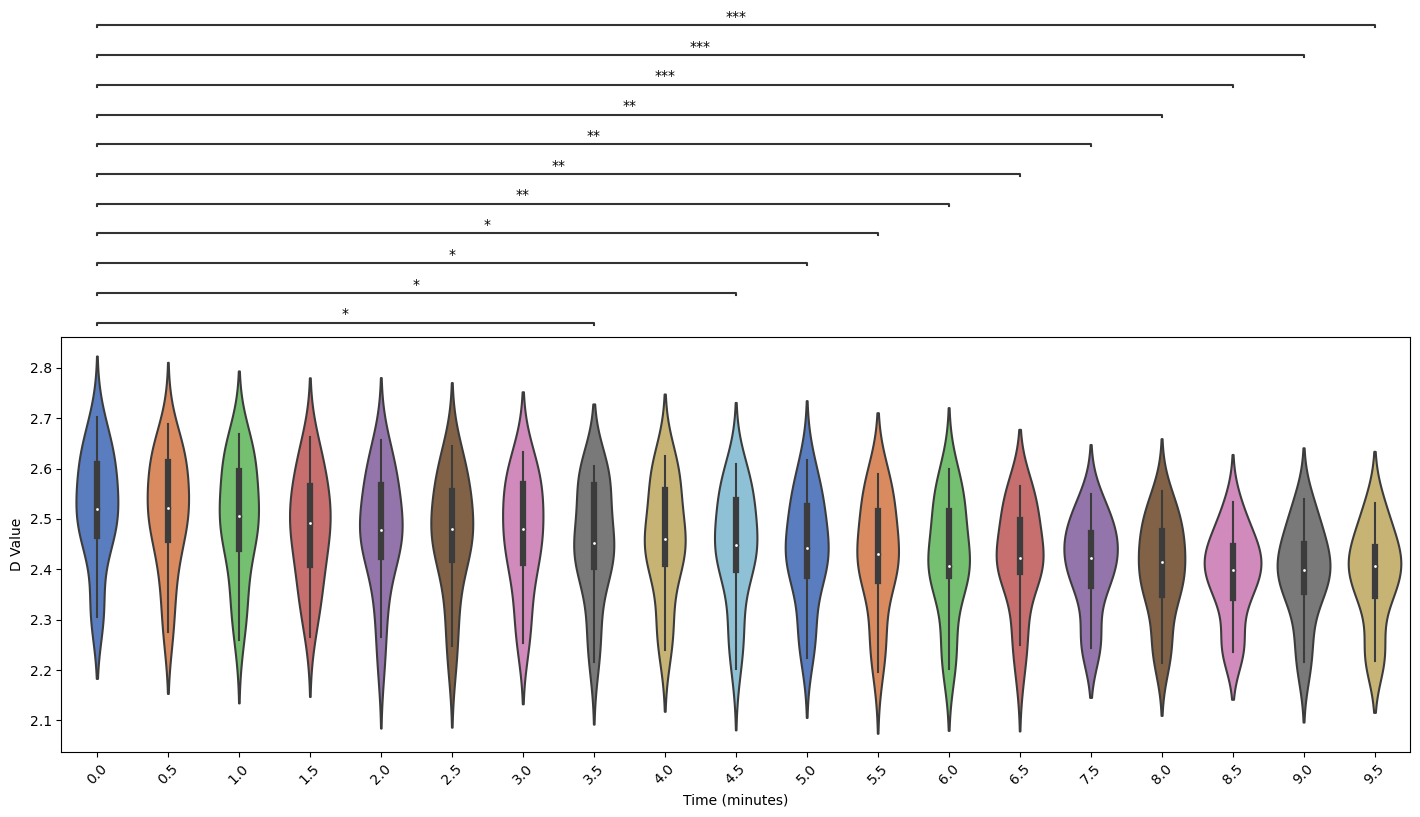

In [33]:
# Create plots

# Exclude Cell# 15 and compute Time (min) -- excluding cell# 15 due to inconsistency in RMS. The FOV for single wavelength also had different intensity
df_D = df_D[df_D['Cell#'].astype(int) != 15].copy()
df_D['Time (min)'] = (df_D['Cell#'].astype(int) - 1) * 0.5

## Global D plot -------------------------------

# Pairwise Comparisons between Cell# 1 (0.0 min) and all other time points
cell_1_time = 0.0
other_times = sorted(df_D['Time (min)'].unique())
comparisons = [(cell_1_time, t) for t in other_times if t != cell_1_time]

# Violinplot with statistical annotations
plt.figure(figsize=(14, 6))
ax = sns.violinplot(data=df_D, x='Time (min)', y='D', palette='muted')
annotator = Annotator(ax, pairs=comparisons, data=df_D, x='Time (min)', y='D')
annotator.configure(test='Mann-Whitney', text_format='star', loc='outside', verbose=0, line_height= 0.005, hide_non_significant = True)
annotator.apply_and_annotate()

# plt.title('Violinplot of D values by Time')
plt.xlabel('Time (minutes)')
plt.ylabel('D Value')
plt.xticks(rotation=45)
plt.tight_layout()

# Finalize and save plot
plt.tight_layout(pad=0, w_pad=0, h_pad=0)
# plt.savefig(save_path + D_file + 'Global_D_value_filtered_Cell15_annotated.png', transparent=True, bbox_inches='tight')
# Show plot and close
plt.show()


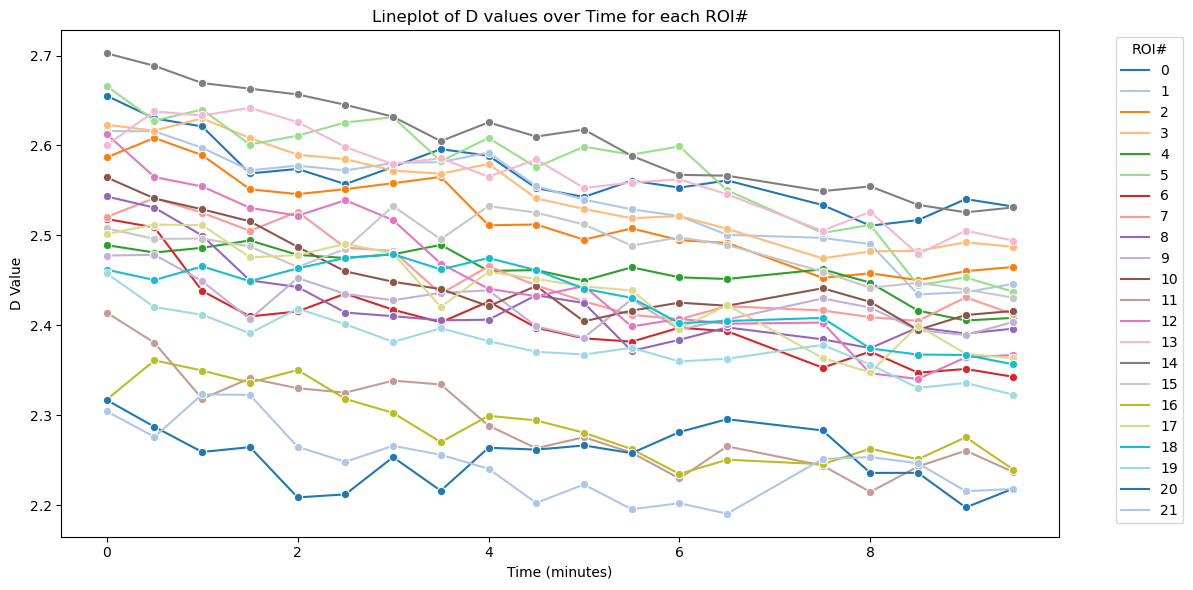

High D ΔD: -0.06773781920342298
Low D ΔD: -0.047482713873988086
Number of high D cells: 6
Number of low D cells: 6
Mann-Whitney U Test:
  Statistic: 6.0
  p-value: 0.06493506493506493


In [41]:
#Each ROI analyses (Line plot, percentile analysis)

# Convert Cell# to int for sorting
df_sorted = df_D.copy()
df_sorted['Cell#'] = df_sorted['Cell#'].astype(int)
df_sorted = df_sorted.sort_values(by='Cell#', ascending=False)

# Individual nucleus lineplot --------------------------------
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_D, x='Time (min)', y='D', hue='ROI#', palette='tab20', marker="o", legend='full')
plt.title('Lineplot of D values over Time for each ROI#')
plt.xlabel('Time (minutes)')
plt.ylabel('D Value')
plt.legend(title='ROI#', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
# plt.savefig(save_path + D_file + 'Each_ROI_Lineplot_filtered_Cell15.png', transparent=True, bbox_inches='tight')
plt.show()

## Comparing initial high D and inital low D cells ----------------------------

# Get initial D values at Cell# 1
roi_initial = df_D[df_D['Cell#'] == 1][['ROI#', 'D']].copy()

# Define percentile thresholds
p25 = roi_initial['D'].quantile(0.25)
p75 = roi_initial['D'].quantile(0.75)

# Classify ROIs
high_D_ROIs = roi_initial[roi_initial['D'] > p75]['ROI#'].unique()
low_D_ROIs = roi_initial[roi_initial['D'] < p25]['ROI#'].unique()

# Function to calculate delta D
def calc_delta_D(group_rois):
    delta_Ds = []
    for roi in group_rois:
        d_start = df_D[(df_D['ROI#'] == roi) & (df_D['Cell#'] == 1)]['D'].values
        d_end = df_D[(df_D['ROI#'] == roi) & (df_D['Cell#'] == 20)]['D'].values
        if len(d_start) > 0 and len(d_end) > 0:
            delta_Ds.append((d_end[0] - d_start[0])/d_start[0])
    return np.array(delta_Ds)

# Calculate ΔD for each group
delta_high = calc_delta_D(high_D_ROIs)
delta_low = calc_delta_D(low_D_ROIs)

# Perform Mann-Whitney U test
stat_result = mannwhitneyu(delta_high, delta_low, alternative='two-sided')

# Output results
print("High D ΔD:", mean(delta_high))
print("Low D ΔD:", mean(delta_low))
print("Number of high D cells:", len(delta_high))
print("Number of low D cells:", len(delta_low))
print("Mann-Whitney U Test:")
print("  Statistic:", stat_result.statistic)
print("  p-value:", stat_result.pvalue)